# 🏙️ Airbnb in New York — Exploratory Data Analysis (EDA)

A company collected **housing rental data in New York** from the **Airbnb platform** during **2019**.  
This dataset was used to train **Machine Learning models** in an open competition during that year.

We will use it to study the dataset variables, understand the data, and draw conclusions.

---

## 📌 Step 1: Loading the Dataset

Download the dataset from Kaggle or from:

https://raw.githubusercontent.com/4GeeksAcademy/data-preprocessing-project-tutorial/main/AB_NYC_2019.csv

Store the raw data in the folder:

`/data/raw`

---

## 📊 Step 2: Perform a Complete EDA

This step is vital to keep only the variables that are strictly necessary and remove those that are not relevant.

Use the example Notebook from the lesson and adapt it to this use case. During EDA:

- Review variables and data types  
- Check missing values  
- Detect inconsistencies and duplicates  
- Explore distributions and relationships  
- Identify potential outliers  
- Remove irrelevant columns and clean the data  

Split the dataset into:

- **Train set**  
- **Test set**  

As shown in the lesson.

---

## 💾 Step 3: Save the Processed Dataset

After EDA, save the processed data in:

`/data/processed`

Add the data folder to `.gitignore`.  
Datasets and trained models should **not** be uploaded to Git.

---

## 📂 Recommended Project Structure

    project
    ├── data
    │   ├── raw
    │   │   └── AB_NYC_2019.csv
    │   └── processed
    ├── notebooks
    ├── src
    └── .gitignore

## Implementation

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
#check the basic information of the data
df = pd.read_csv('../data/raw/AB_NYC_2019.csv')

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [4]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [5]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [6]:
#check missing value
missing_value = df.isnull().sum()
print(missing_value)

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [7]:
#checking duplicate values
duplicate_value = df.duplicated()
print(duplicate_value)
print(duplicate_value.sum())

0        False
1        False
2        False
3        False
4        False
         ...  
48890    False
48891    False
48892    False
48893    False
48894    False
Length: 48895, dtype: bool
0


In [8]:
#check duplicate values for specific columns
print(df['id'].duplicated().sum())
print(df['name'].duplicated().sum())
print(df['host_id'].duplicated().sum())
print(df['host_name'].duplicated().sum())

0
989
11438
37442


## Duplicate Value Analysis

- The dataset contains **no duplicated rows**.

- The column **`id`** is unique, confirming that each listing represents a distinct Airbnb property.

- Duplicate values in **`name`**, **`host_id`**, and **`host_name`** are expected because:
  - Multiple listings can share the **same title**.
  - A single host can manage **multiple listings**.
  - Different hosts may have the **same name**.

Therefore, these duplicates **do not indicate data quality issues** and are normal for the Airbnb dataset.

In [9]:
#check inconsistency for categorical variables, which contain text labels, and text data is more likely to have formatting problems.
df['room_type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

In [10]:
df['neighbourhood_group'].unique()

<StringArray>
['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx']
Length: 5, dtype: str

In [11]:
df['neighbourhood'].unique()

<StringArray>
[        'Kensington',            'Midtown',             'Harlem',
       'Clinton Hill',        'East Harlem',        'Murray Hill',
 'Bedford-Stuyvesant',     'Hell's Kitchen',    'Upper West Side',
          'Chinatown',
 ...
     'Fort Wadsworth',           'Rosebank',          'Unionport',
         'Mill Basin',      'Arden Heights',        'Bull's Head',
           'New Dorp',          'Rossville',       'Breezy Point',
        'Willowbrook']
Length: 221, dtype: str

In [12]:
df['neighbourhood'].nunique()

221

In [13]:
df['neighbourhood'].str.lower().nunique()

221

### Consistency Check for Categorical Columns

The columns `room_type`, `neighbourhood_group`, and `neighbourhood` were analyzed to detect potential inconsistencies in text formatting.

To verify whether different capitalizations represented the same category, the number of unique values was compared with a lowercase transformation of the same columns.

The results were identical in both cases, indicating that there are **no inconsistencies caused by capitalization differences**. Therefore, the categorical values in these columns are **consistently formatted**.

In [14]:
#explore distributions and relationships
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### General Overview of the Dataset

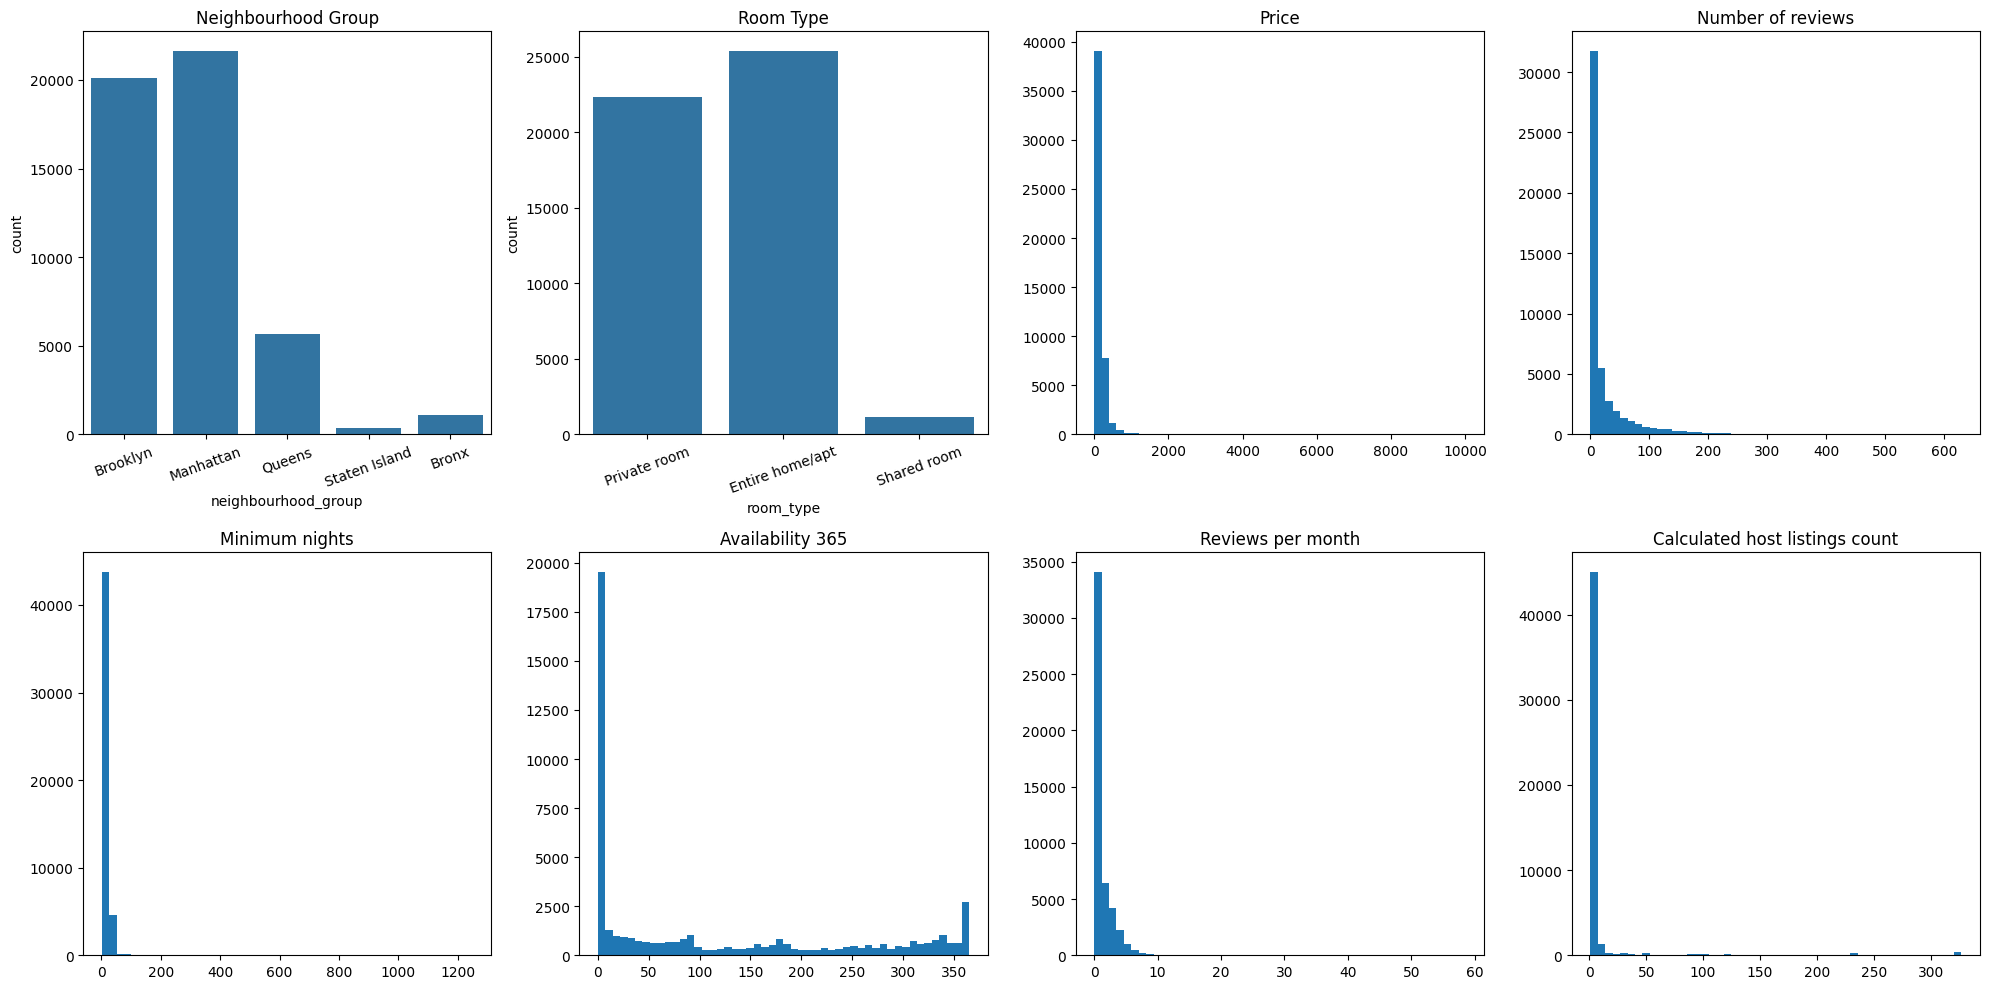

In [15]:
fig, axis = plt.subplots(2, 4, figsize=(20, 10))

sns.countplot(data=df, x="neighbourhood_group", ax=axis[0, 0])
axis[0, 0].set_title("Neighbourhood Group")
axis[0, 0].tick_params(axis='x', rotation=20)

sns.countplot(data=df, x="room_type", ax=axis[0, 1])
axis[0, 1].set_title("Room Type")
axis[0, 1].tick_params(axis='x', rotation=20)

axis[0, 2].hist(df["price"].dropna(), bins=50)
axis[0, 2].set_title("Price")

axis[0, 3].hist(df["number_of_reviews"].dropna(), bins=50)
axis[0, 3].set_title("Number of reviews")

axis[1, 0].hist(df["minimum_nights"].dropna(), bins=50)
axis[1, 0].set_title("Minimum nights")

axis[1, 1].hist(df["availability_365"].dropna(), bins=50)
axis[1, 1].set_title("Availability 365")

axis[1, 2].hist(df["reviews_per_month"].fillna(0), bins=50)
axis[1, 2].set_title("Reviews per month")

axis[1, 3].hist(df["calculated_host_listings_count"].dropna(), bins=50)
axis[1, 3].set_title("Calculated host listings count")

plt.tight_layout()
plt.show()

### Price Distribution

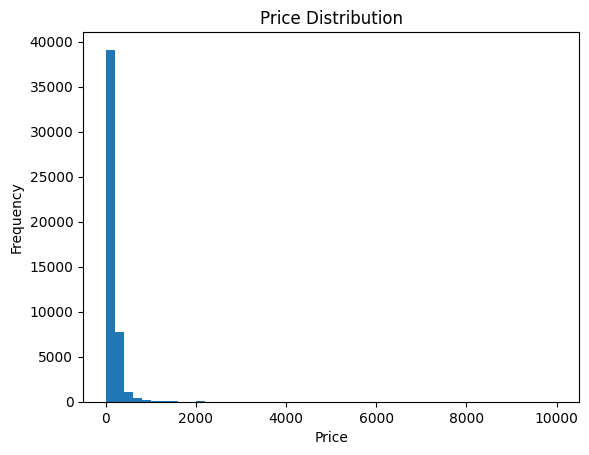

In [16]:
plt.hist(df['price'], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

### Room Type Distribution

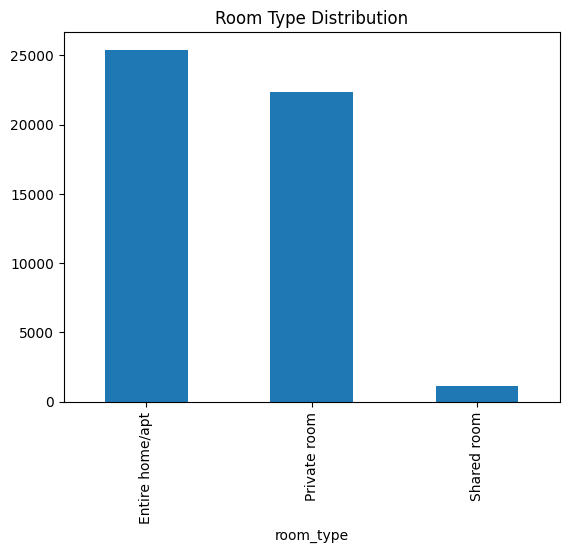

In [17]:
df['room_type'].value_counts().plot(kind='bar')
plt.title("Room Type Distribution")
plt.show()

### Neighbourhood Group Type Distribution

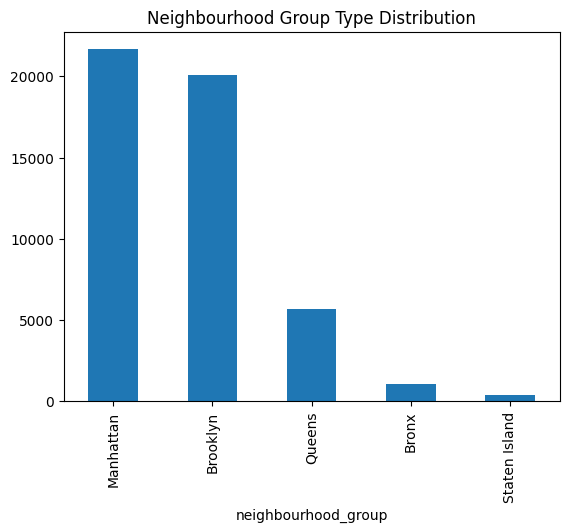

In [18]:
df['neighbourhood_group'].value_counts().plot(kind='bar')
plt.title("Neighbourhood Group Type Distribution")
plt.show()

### Price Distribution by Room Type

The boxplot shows that **entire homes or apartments have the highest median price**, while **shared rooms are the cheapest accommodation type**. **Private rooms** fall in between these two categories.

The plot also reveals **many price outliers**, indicating the presence of **very expensive listings compared to the majority of the dataset**.

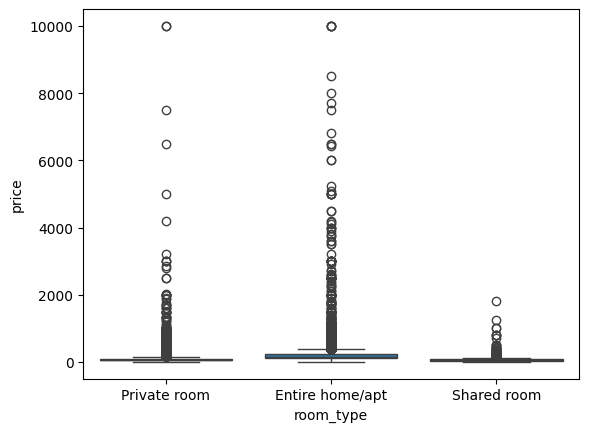

In [19]:
#price vs room type
sns.boxplot(x='room_type', y='price', data=df)
plt.show()

### Price Distribution by Neighbourhood Group

The boxplot shows that **Manhattan has the highest median listing price**, followed by **Brooklyn**. Queens, Staten Island, and the Bronx generally have lower prices.

The plot also reveals many **price outliers**, particularly in Manhattan and Brooklyn, indicating the presence of very expensive listings compared to the typical price range.

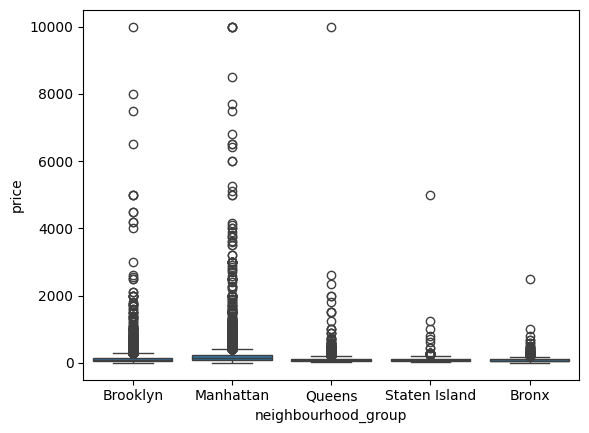

In [20]:
#price vs neighbourhood group
sns.boxplot(x='neighbourhood_group', y='price', data=df)
plt.show()

### Price Patterns Based on Listing Popularity
Most points are concentrated near the lower part of the price axis, indicating that the majority of listings have relatively low prices. A smaller number of listings appear as outliers with very high prices. Additionally, listings with a higher number of reviews tend to fall within the lower price range.

> **Note:** In the Airbnb dataset, a **listing** refers to a property or accommodation published on the Airbnb platform. A listing can be an **entire home or apartment**, a **private room**, or a **shared room**. In most cases, **one row in the dataset represents one listing**.

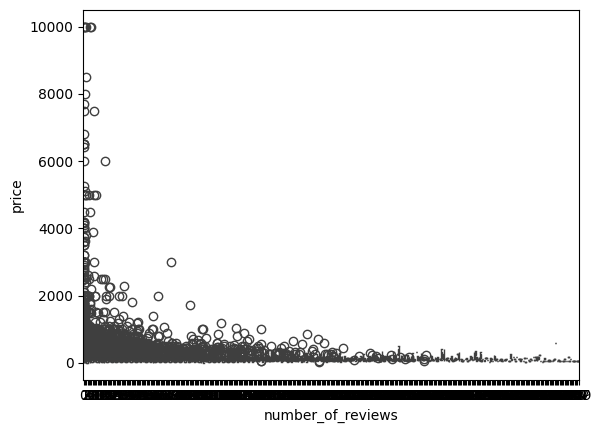

In [21]:
#reviews vs price
sns.boxplot(x='number_of_reviews', y='price', data=df)
plt.show()

### Correlation Analysis

The heatmap shows the correlations between the numeric variables in the Airbnb dataset. In general, most correlations are **weak**, which suggests that the variables are relatively independent from each other and that there are no strong linear relationships in most cases.

#### Main observations

- The strongest positive correlation is between **`number_of_reviews`** and **`reviews_per_month`** (**0.55**). This indicates that listings with more total reviews also tend to receive more reviews per month.

- There is a moderate positive correlation between **`id`** and **`host_id`** (**0.59**). This likely reflects how identifiers were assigned, but it does not provide meaningful business insight for the analysis.

- **`host_id`** and **`reviews_per_month`** show a weak to moderate positive correlation (**0.30**), while **`id`** and **`reviews_per_month`** also show a weak positive correlation (**0.29**). These relationships are not especially useful for interpretation, since `id` and `host_id` are identifiers rather than real explanatory variables.

- **`id`** and **`number_of_reviews`** have a moderate negative correlation (**-0.32**). This may suggest that newer listings, which tend to have larger IDs, have accumulated fewer reviews.

- **`longitude`** and **`price`** show a weak negative correlation (**-0.15**), indicating that location may have some small effect on price, but the relationship is not strong.

- **`minimum_nights`** has very weak correlations with most variables. For example, it has a small negative correlation with **`reviews_per_month`** (**-0.12**) and **`number_of_reviews`** (**-0.08**), suggesting that listings requiring longer stays may receive slightly fewer reviews.

- **`calculated_host_listings_count`** and **`availability_365`** have a weak positive correlation (**0.23**). This may indicate that hosts with more listings tend to keep their properties available for more days during the year.

- **`availability_365`** has weak positive correlations with **`reviews_per_month`** (**0.19**) and **`number_of_reviews`** (**0.17**), suggesting only a slight relationship between availability and review activity.

#### Conclusion

Overall, the heatmap suggests that the dataset does not contain many strong linear relationships between numeric variables. The most relevant relationship is between **`number_of_reviews`** and **`reviews_per_month`**, while most other correlations are weak and should be interpreted carefully. Variables such as **`id`** and **`host_id`** are identifiers, so their correlations are not especially meaningful for modeling or business interpretation.

> **Note:** Correlation values range from **-1 to 1**.  
> **1** indicates a perfect positive relationship, **0** indicates no relationship, and **-1** indicates a perfect negative relationship.  
> A **positive correlation** means that when one variable increases, the other tends to increase as well.  
> A **negative correlation** means that when one variable increases, the other tends to decrease.

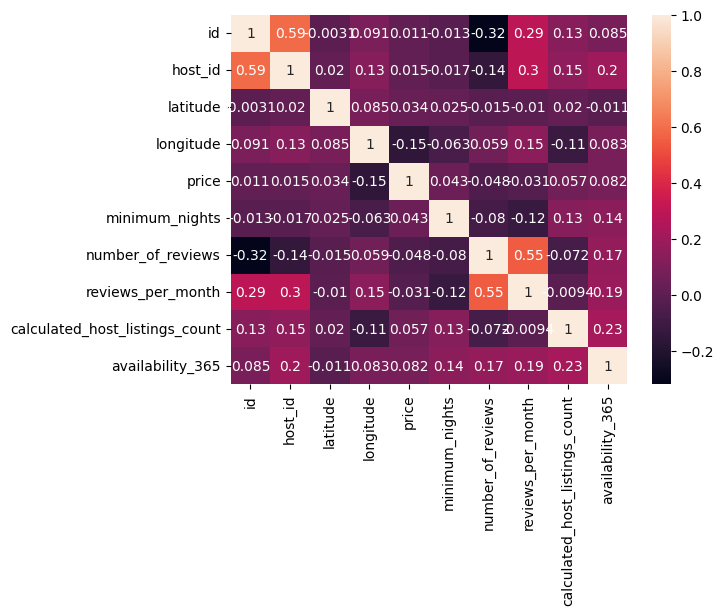

In [24]:
#correlations between numeric variables
df.corr(numeric_only=True) #calculates the correlation matrix for all numeric columns
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

### Removing Irrelevant Columns

To clean the dataset, some columns were removed because they are not useful for analysis or modeling. In particular, `id` and `host_id` are only identifiers, while `name` and `host_name` are text fields with limited predictive value in this context. The column `last_review` was also removed because it contains many missing values and is less relevant for a basic preprocessing workflow.

The removed columns are:

- `id`
- `name`
- `host_id`
- `host_name`
- `last_review`

In [25]:
df = df.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'])
df

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,6,2


### Train-Test Split

After cleaning the dataset, the data was divided into a **training set** and a **test set**.

- The **training set** is used to train the model.
- The **test set** is used to evaluate the model on unseen data.

A common split ratio of **80% for training** and **20% for testing** was used.

> **Note:** The column `price` is removed from `X` because it is the **target variable**. `y` is the `price` column because `price` is the **target variable** in this exercise. In a machine learning problem, `X` contains the input features, while `y` contains the value the model is supposed to predict. If `price` were kept inside `X`, the model would be using the answer as an input, which would be incorrect.<br><br>
`X` = all columns except price<br>
`y` = price

> **Note:** `test_size=0.2` means that 20% of the dataset is used for testing and the remaining 80% is used for training.  
> `random_state=42` ensures that the split is reproducible, meaning the same rows will be assigned to the train and test sets every time the code is run.

In [ ]:
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [29]:
train_data = X_train.copy()
train_data['price'] = y_train

test_data = X_test.copy()
test_data['price'] = y_test

train_data.to_csv('../data/processed/train_data.csv', index=False)
test_data.to_csv('../data/processed/test_data.csv', index=False)